# Modelo desde 0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define las rutas exactas de tus carpetas
ruta_train = '/content/drive/MyDrive/chest_xray/train'
ruta_test = '/content/drive/MyDrive/chest_xray/test'

# 2. Configurar Data Augmentation para el conjunto de entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalizar píxeles
    rotation_range=15,       # Rotación leve
    zoom_range=0.2,          # Zoom leve
    horizontal_flip=True     # Efecto espejo
)

# Para el test NO hacemos augmentation, solo normalizamos
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Cargar las imágenes en lotes (batches)
print("Cargando imágenes de entrenamiento:")
train_generator = train_datagen.flow_from_directory(
    ruta_train,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'  # IMPORTANTE: 'binary' porque solo hay 2 carpetas (Normal/Pneumonia)
)

print("Cargando imágenes de prueba:")
test_generator = test_datagen.flow_from_directory(
    ruta_test,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # No mezclar el test para evaluar correctamente después
)

Cargando imágenes de entrenamiento:
Found 5232 images belonging to 2 classes.
Cargando imágenes de prueba:
Found 624 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

modelo = models.Sequential([
    # Primer bloque convolucional
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),

    # Segundo bloque
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Tercer bloque
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Aplanar la imagen para pasarla a las neuronas tradicionales
    layers.Flatten(),

    # Capas densas de decisión
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Previene el sobreajuste

    # Capa de salida: 1 sola neurona (0 = Normal, 1 = Neumonía)
    layers.Dense(1, activation='sigmoid')
])

modelo.summary() # Esto te mostrará un resumen de la arquitectura

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Definir cómo aprenderá el modelo
modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Usamos binary porque son 2 clases
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# ¡Iniciamos el entrenamiento!
print("Iniciando entrenamiento...")
historial = modelo.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Iniciando entrenamiento...
Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 727s 4s/step - accuracy: 0.7991 - loss: 0.4285 - recall: 0.9325 - val_accuracy: 0.8846 - val_loss: 0.2918 - val_recall: 0.9128
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 125s 761ms/step - accuracy: 0.8798 - loss: 0.2922 - recall: 0.9356 - val_accuracy: 0.8606 - val_loss: 0.3027 - val_recall: 0.9744
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 126s 766ms/step - accuracy: 0.8977 - loss: 0.2476 - recall: 0.9366 - val_accuracy: 0.9167 - val_loss: 0.2147 - val_recall: 0.9590
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 126s 767ms/step - accuracy: 0.9004 - loss: 0.2345 - recall: 0.9382 - val_accuracy: 0.9071 - val_loss: 0.2211 - val_recall: 0.9615
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 128s 779ms/step - accuracy: 0.9172 - loss: 0.2127 - recall: 0.9477 - val_accuracy: 0.9103 - val_loss: 0.2264 - val_recall: 0.9821
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 128s 779ms/step - accuracy: 0.9197 - loss: 0.1987 - recall: 0.9536 - val_accuracy: 0.9

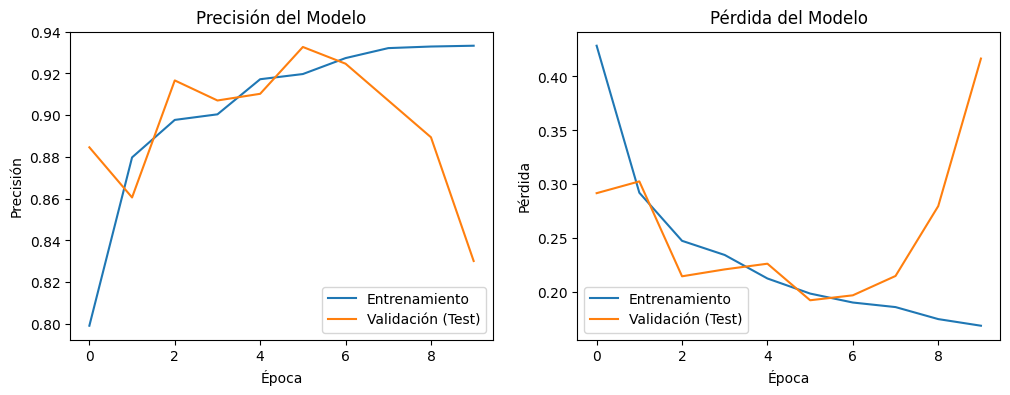

In [ ]:
import matplotlib.pyplot as plt

# Graficar la Precisión (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación (Test)')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Graficar la Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación (Test)')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

Generando predicciones... esto tomará unos segundos.
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 358ms/step


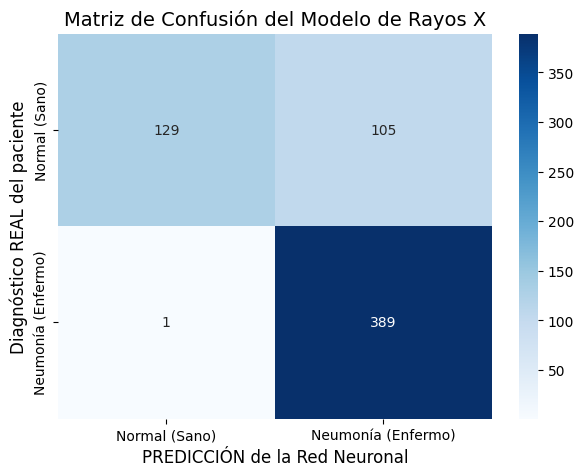


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Normal       0.99      0.55      0.71       234
    Neumonía       0.79      1.00      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.77      0.79       624
weighted avg       0.86      0.83      0.82       624



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Reiniciar el generador de prueba para que las predicciones coincidan con las etiquetas reales
test_generator.reset()

# 2. Pedirle al modelo que diagnostique las imágenes de prueba
print("Generando predicciones... esto tomará unos segundos.")
predicciones_probabilidad = modelo.predict(test_generator)

# Como el modelo da probabilidades (ej. 0.8), lo convertimos a 1 (Neumonía) o 0 (Normal)
# Si es mayor a 0.5, el modelo dice que es Neumonía
predicciones_clases = np.where(predicciones_probabilidad > 0.5, 1, 0)

# 3. Obtener los diagnósticos reales (las respuestas correctas)
clases_reales = test_generator.classes

# 4. Crear la matriz de confusión
matriz = confusion_matrix(clases_reales, predicciones_clases)

# 5. ¡Dibujarla para que se vea profesional!
plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (Sano)', 'Neumonía (Enfermo)'],
            yticklabels=['Normal (Sano)', 'Neumonía (Enfermo)'])

plt.title('Matriz de Confusión del Modelo de Rayos X', fontsize=14)
plt.ylabel('Diagnóstico REAL del paciente', fontsize=12)
plt.xlabel('PREDICCIÓN de la Red Neuronal', fontsize=12)
plt.show()

# Extra: Un reporte de texto con métricas detalladas
print("\n--- Reporte de Clasificación ---")
print(classification_report(clases_reales, predicciones_clases, target_names=['Normal', 'Neumonía']))

Generando predicciones... esto tomará unos segundos.
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step


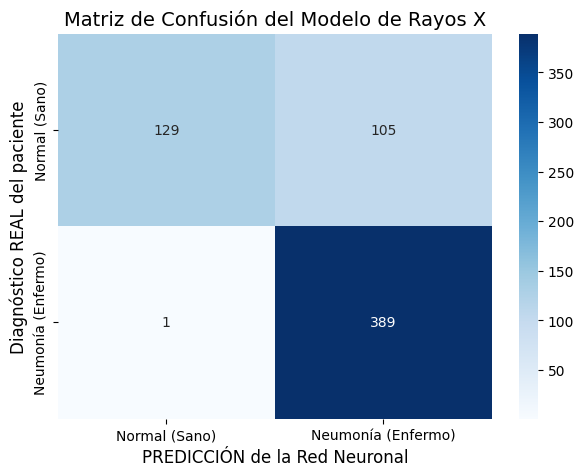


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Normal       0.99      0.55      0.71       234
    Neumonía       0.79      1.00      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.77      0.79       624
weighted avg       0.86      0.83      0.82       624



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Reiniciar el generador de prueba para que las predicciones coincidan en orden con las etiquetas reales
test_generator.reset()

# 2. Pedirle al modelo que diagnostique las imágenes de prueba
print("Generando predicciones... esto tomará unos segundos.")
predicciones_probabilidad = modelo.predict(test_generator)

# Como el modelo da probabilidades (ej. 0.8), lo convertimos a 1 (Neumonía) o 0 (Normal)
# Si la probabilidad es mayor a 0.5, el modelo diagnostica Neumonía
predicciones_clases = np.where(predicciones_probabilidad > 0.5, 1, 0)

# 3. Obtener los diagnósticos reales (las respuestas correctas de los médicos)
clases_reales = test_generator.classes

# 4. Calcular la matriz de confusión
matriz = confusion_matrix(clases_reales, predicciones_clases)

# 5. ¡Dibujarla para que se vea profesional!
plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (Sano)', 'Neumonía (Enfermo)'],
            yticklabels=['Normal (Sano)', 'Neumonía (Enfermo)'])

plt.title('Matriz de Confusión del Modelo de Rayos X', fontsize=14)
plt.ylabel('Diagnóstico REAL del paciente', fontsize=12)
plt.xlabel('PREDICCIÓN de la Red Neuronal', fontsize=12)
plt.show()

# Extra: Un reporte de texto con métricas detalladas
print("\n--- Reporte de Clasificación ---")
print(classification_report(clases_reales, predicciones_clases, target_names=['Normal', 'Neumonía']))

GRAM CAM

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generar_heatmap_gradcam(img_array, modelo):
    # 1. Encontrar la última capa convolucional
    ultima_capa_conv = None
    for capa in reversed(modelo.layers):
        if 'conv2d' in capa.name:
            ultima_capa_conv = capa.name
            break

    if ultima_capa_conv is None:
        raise ValueError("No se encontró ninguna capa Conv2D.")

    # 2. MÉTODO EAGER (A prueba de balas contra errores de Keras 3)
    with tf.GradientTape() as tape:
        # Asegurarnos de que la imagen sea un tensor válido
        x = tf.cast(img_array, tf.float32)
        salida_conv = None

        # Pasar la imagen capa por capa manualmente
        for capa in modelo.layers:
            # Apagar el dropout para que no interfiera en el análisis
            if 'dropout' in capa.name:
                x = capa(x, training=False)
            else:
                x = capa(x)

            # Cuando pasemos por la última convolución, le decimos a la "Cinta" que grabe este punto
            if capa.name == ultima_capa_conv:
                salida_conv = x
                tape.watch(salida_conv)

        # Al salir del bucle, 'x' es la predicción final (probabilidad de Neumonía)
        loss = x[:, 0]

    # 3. Calcular los gradientes directos sin usar tf.keras.Model
    grads = tape.gradient(loss, salida_conv)

    # Promediar los gradientes
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiplicar la salida por los gradientes
    salida_conv = salida_conv[0]
    heatmap = salida_conv @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizar el heatmap para que los colores se vean bien (valores de 0 a 1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step
El modelo dice que es: Neumonía (Certeza: 99.98%)


/tmp/ipykernel_8112/823692237.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet") # Usar el mapa de colores "jet" (azul a rojo)


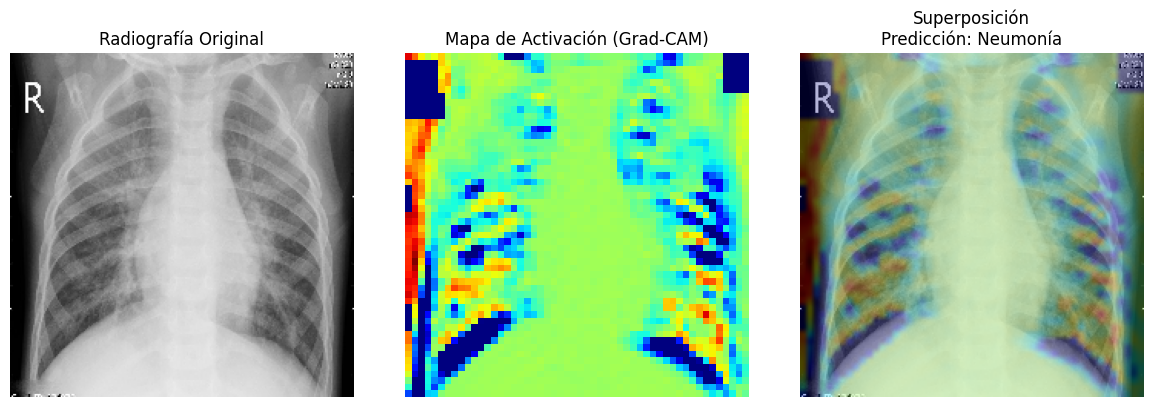

In [ ]:
from tensorflow.keras.preprocessing import image

# --- 1. PON AQUÍ LA RUTA DE UNA IMAGEN CON NEUMONÍA DE TU CARPETA TEST ---
ruta_imagen_prueba = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/VIRUS-1056329-0001.jpeg'  # NORMAL/NORMAL-11419-0001.jpeg' # BACTERIA-40699-0002.jpeg' # <-- Cambia esto por tu ruta real

# 2. Cargar y preparar la imagen para el modelo
img = image.load_img(ruta_imagen_prueba, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0 # Normalizar igual que en el entrenamiento

# 3. Hacer la predicción
prediccion = modelo.predict(img_array)[0][0]
diagnostico = "Neumonía" if prediccion > 0.5 else "Normal"
certeza = prediccion if prediccion > 0.5 else 1 - prediccion

print(f"El modelo dice que es: {diagnostico} (Certeza: {certeza:.2%})")

# 4. Generar el Heatmap
heatmap = generar_heatmap_gradcam(img_array, modelo)

# 5. Superponer el Heatmap sobre la radiografía original
img_original = image.img_to_array(img)
heatmap_redimensionado = np.uint8(255 * heatmap) # Escalar a 0-255
jet = cm.get_cmap("jet") # Usar el mapa de colores "jet" (azul a rojo)

# Colorear el heatmap
colores_jet = jet(np.arange(256))[:, :3]
heatmap_coloreado = colores_jet[heatmap_redimensionado]

# Redimensionar el heatmap al tamaño de la imagen original
heatmap_coloreado = tf.keras.preprocessing.image.array_to_img(heatmap_coloreado)
heatmap_coloreado = heatmap_coloreado.resize((img_original.shape[1], img_original.shape[0]))
heatmap_coloreado = tf.keras.preprocessing.image.img_to_array(heatmap_coloreado)

# Mezclar la imagen original con el heatmap (el 0.4 es la intensidad del color)
imagen_superpuesta = heatmap_coloreado * 0.4 + img_original
imagen_superpuesta = tf.keras.preprocessing.image.array_to_img(imagen_superpuesta)

# 6. ¡Dibujar todo!
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Radiografía Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Mapa de Activación (Grad-CAM)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_superpuesta)
plt.title(f"Superposición\nPredicción: {diagnostico}")
plt.axis('off')

plt.tight_layout()
plt.show()

# Modelo usando VGG16

In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. Conectar a Drive
drive.mount('/content/drive')

# 2. Rutas
ruta_train = '/content/drive/MyDrive/chest_xray/train'
ruta_test = '/content/drive/MyDrive/chest_xray/test'

# 3. Generadores (¡Usando preprocess_input de VGG16!)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Esto prepara la imagen para VGG16
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Cargando entrenamiento:")
train_generator = train_datagen.flow_from_directory(
    ruta_train, target_size=(224, 224), batch_size=32, class_mode='binary')

print("Cargando prueba:")
test_generator = test_datagen.flow_from_directory(
    ruta_test, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando entrenamiento:
Found 5232 images belonging to 2 classes.
Cargando prueba:
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# 1. Descargar el modelo VGG16 pre-entrenado (sin su capa final original)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Congelar el modelo base (para no destruir su conocimiento previo)
base_model.trainable = False

# 3. Construir nuestro modelo usando la API Funcional (mucho más profesional y sin bugs)
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Nuestra "cabeza" clasificadora
x = layers.GlobalAveragePooling2D()(x) # Mejor alternativa al Flatten
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x) # 1 = Neumonía, 0 = Normal

# Unimos todo
modelo_experto = tf.keras.Model(inputs, outputs)

# Compilar
modelo_experto.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

modelo_experto.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
print("Iniciando entrenamiento con Transfer Learning...")
historial = modelo_experto.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Iniciando entrenamiento con Transfer Learning...
Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 164s 887ms/step - accuracy: 0.8788 - loss: 0.3832 - recall: 0.9220 - val_accuracy: 0.8702 - val_loss: 0.3032 - val_recall: 0.9795
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 827ms/step - accuracy: 0.9300 - loss: 0.1882 - recall: 0.9544 - val_accuracy: 0.9199 - val_loss: 0.2054 - val_recall: 0.9744
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 831ms/step - accuracy: 0.9383 - loss: 0.1570 - recall: 0.9591 - val_accuracy: 0.9295 - val_loss: 0.1856 - val_recall: 0.9769
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s 852ms/step - accuracy: 0.9478 - loss: 0.1437 - recall: 0.9642 - val_accuracy: 0.9215 - val_loss: 0.2010 - val_recall: 0.9769
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 139s 845ms/step - accuracy: 0.9547 - loss: 0.1242 - recall: 0.9706 - val_accuracy: 0.9359 - val_loss: 0.1775 - val_recall: 0.9615
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 858ms/step - accuracy: 0.9513 - loss: 0.1290 - recall: 0

Generando predicciones con VGG16...
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 464ms/step


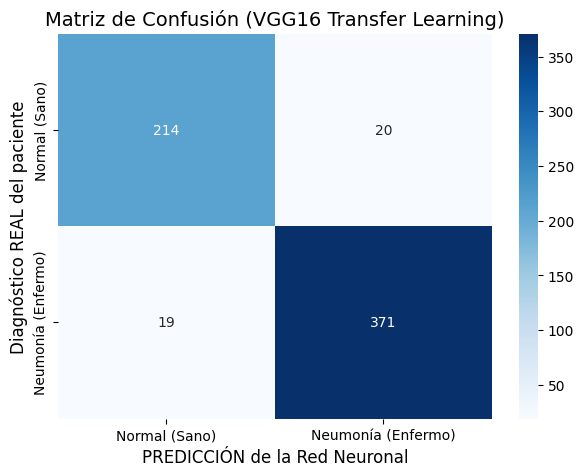


--- Reporte de Clasificación (VGG16) ---
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.92       234
    Neumonía       0.95      0.95      0.95       390

    accuracy                           0.94       624
   macro avg       0.93      0.93      0.93       624
weighted avg       0.94      0.94      0.94       624



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. Reiniciar el generador
test_generator.reset()

# 2. Generar predicciones con el modelo VGG16
print("Generando predicciones con VGG16...")
# IMPORTANTE: Como VGG16 requiere preprocess_input, debemos pasarlo al predecir en lote
predicciones_probabilidad = modelo_experto.predict(test_generator)

# Convertir a 0 y 1
predicciones_clases = np.where(predicciones_probabilidad > 0.5, 1, 0)
clases_reales = test_generator.classes

# 3. Matriz de Confusión
matriz = confusion_matrix(clases_reales, predicciones_clases)

# 4. Dibujar
plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (Sano)', 'Neumonía (Enfermo)'],
            yticklabels=['Normal (Sano)', 'Neumonía (Enfermo)'])

plt.title('Matriz de Confusión (VGG16 Transfer Learning)', fontsize=14)
plt.ylabel('Diagnóstico REAL del paciente', fontsize=12)
plt.xlabel('PREDICCIÓN de la Red Neuronal', fontsize=12)
plt.show()

print("\n--- Reporte de Clasificación (VGG16) ---")
print(classification_report(clases_reales, predicciones_clases, target_names=['Normal', 'Neumonía']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicción del modelo experto: Neumonía (99.79%)


/tmp/ipykernel_8112/1061775520.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


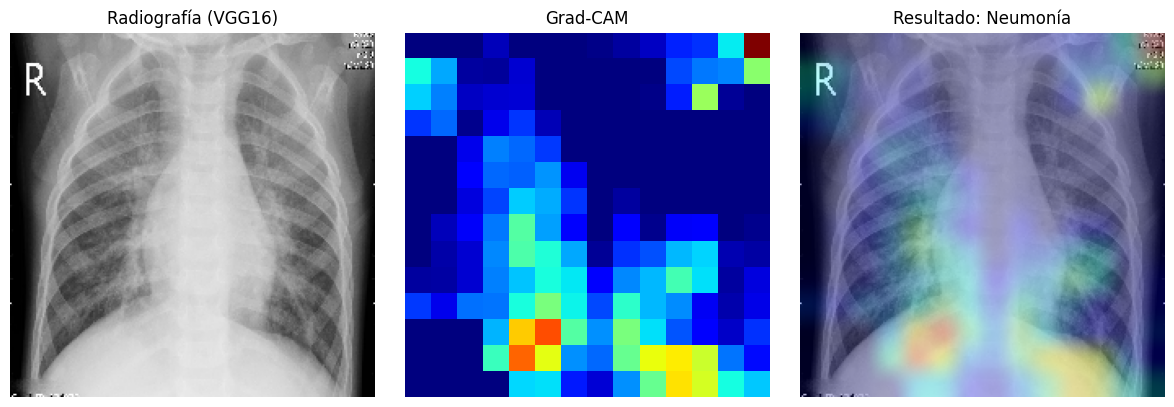

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

def generar_heatmap_vgg16(img_array, modelo_experto, modelo_base):
    with tf.GradientTape() as tape:
        x = tf.cast(img_array, tf.float32)
        salida_conv = None

        # 1. Entramos al "Cerebro" de VGG16
        for capa in modelo_base.layers:
            # EL PARCHE: Si es una capa de entrada, la saltamos para evitar el TypeError
            if isinstance(capa, tf.keras.layers.InputLayer):
                continue

            x = capa(x)

            # Empezamos a grabar en la última convolución
            if capa.name == 'block5_conv3':
                salida_conv = x
                tape.watch(salida_conv)

        # 2. Pasamos por la "Cabeza" clasificadora
        for capa in modelo_experto.layers:
            # Saltamos la capa de entrada general y el modelo base entero (porque ya lo recorrimos arriba)
            if isinstance(capa, tf.keras.layers.InputLayer) or capa.name == 'vgg16':
                continue

            if 'dropout' in capa.name.lower():
                x = capa(x, training=False)
            else:
                x = capa(x)

        # 3. Probabilidad final de Neumonía
        loss = x[:, 0]

    # 4. Calcular qué píxeles importaron más
    grads = tape.gradient(loss, salida_conv)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    salida_conv = salida_conv[0]
    heatmap = salida_conv @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizar los colores
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- DIBUJAR TODO ---
ruta_imagen = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/VIRUS-1056329-0001.jpeg'

img = image.load_img(ruta_imagen, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array_expanded = np.expand_dims(img_array, axis=0)
img_preprocesada = preprocess_input(img_array_expanded)

# Predicción
prediccion = modelo_experto.predict(img_preprocesada)[0][0]
diagnostico = "Neumonía" if prediccion > 0.5 else "Normal"
print(f"Predicción del modelo experto: {diagnostico} ({(prediccion if prediccion>0.5 else 1-prediccion):.2%})")

# Generar Heatmap
heatmap = generar_heatmap_vgg16(img_preprocesada, modelo_experto, base_model)

# Colorear y Superponer
img_original = image.img_to_array(img)
heatmap_resized = np.uint8(255 * heatmap)
jet = cm.get_cmap("jet")
colores_jet = jet(np.arange(256))[:, :3]
heatmap_coloreado = colores_jet[heatmap_resized]
heatmap_coloreado = tf.keras.preprocessing.image.array_to_img(heatmap_coloreado)
heatmap_coloreado = heatmap_coloreado.resize((img_original.shape[1], img_original.shape[0]))
heatmap_coloreado = tf.keras.preprocessing.image.img_to_array(heatmap_coloreado)

imagen_superpuesta = heatmap_coloreado * 0.4 + img_original
imagen_superpuesta = tf.keras.preprocessing.image.array_to_img(imagen_superpuesta)

# Graficar
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Radiografía (VGG16)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_superpuesta)
plt.title(f"Resultado: {diagnostico}")
plt.axis('off')
plt.tight_layout()
plt.show()

# Sección nueva

In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. Conectar a Drive
drive.mount('/content/drive')

# 2. Rutas
ruta_train = '/content/drive/MyDrive/chest_xray/train'
ruta_test = '/content/drive/MyDrive/chest_xray/test'

# 3. Generadores (¡Usando preprocess_input de VGG16!)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Esto prepara la imagen para VGG16
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Cargando entrenamiento:")
train_generator = train_datagen.flow_from_directory(
    ruta_train, target_size=(224, 224), batch_size=32, class_mode='binary')

print("Cargando prueba:")
test_generator = test_datagen.flow_from_directory(
    ruta_test, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando entrenamiento:
Found 5232 images belonging to 2 classes.
Cargando prueba:
Found 624 images belonging to 2 classes.


Calculando pesos de clase...
Pesos asignados: NORMAL (0): 1.94, NEUMONÍA (1): 0.67

Construyendo arquitectura VGG16...

--- INICIANDO FASE 1: Entrenamiento de capas superiores ---
Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 148s 873ms/step - Recall: 0.8661 - accuracy: 0.8727 - loss: 2.3101 - val_Recall: 0.9718 - val_accuracy: 0.9327 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 137s 835ms/step - Recall: 0.9145 - accuracy: 0.9228 - loss: 0.1942 - val_Recall: 0.9487 - val_accuracy: 0.9343 - val_loss: 0.1782 - learning_rate: 0.0010
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 139s 848ms/step - Recall: 0.9225 - accuracy: 0.9310 - loss: 0.1818 - val_Recall: 0.9769 - val_accuracy: 0.9535 - val_loss: 0.1347 - learning_rate: 0.0010
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s 852ms/step - Recall: 0.9426 - accuracy: 0.9469 - loss: 0.1546 - val_Recall: 0.9718 - val_accuracy: 0.9583 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 5/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s

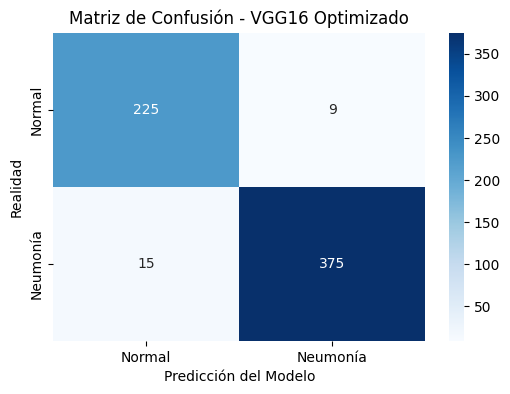

In [ ]:
# ==========================================
# MODELO VGG16 OPTIMIZADO (CALIBRACIÓN AVANZADA)
# ==========================================

import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. CÁLCULO DE PESOS DE CLASE (CLASS WEIGHTS)
# ---------------------------------------------------------
print("Calculando pesos de clase...")
# Obtenemos las etiquetas reales del generador de entrenamiento
etiquetas_train = train_generator.classes

# Calculamos los pesos para balancear la diferencia entre Normal y Neumonía
pesos_calculados = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(etiquetas_train),
    y=etiquetas_train
)

pesos_clases = {0: pesos_calculados[0], 1: pesos_calculados[1]}
print(f"Pesos asignados: NORMAL (0): {pesos_clases[0]:.2f}, NEUMONÍA (1): {pesos_clases[1]:.2f}")

# ---------------------------------------------------------
# 2. CONSTRUCCIÓN DEL MODELO BASE (VGG16)
# ---------------------------------------------------------
print("\nConstruyendo arquitectura VGG16...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelamos toda la base convolucional en la Fase 1
base_model.trainable = False

# Creamos el modelo secuencial añadiendo nuestra propia cabeza
modelo_optimizado = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Regularización
    Dense(1, activation='sigmoid') # Clasificación binaria
])

# Compilamos para la Fase 1
modelo_optimizado.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Recall']
)

# ---------------------------------------------------------
# 3. DEFINICIÓN DE CALLBACKS
# ---------------------------------------------------------
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

# ---------------------------------------------------------
# 4. FASE 1: ENTRENAMIENTO DE LA CABEZA DEL MODELO
# ---------------------------------------------------------
print("\n--- INICIANDO FASE 1: Entrenamiento de capas superiores ---")
history_fase1 = modelo_optimizado.fit(
    train_generator,
    epochs=15, # Ponemos 15, pero el EarlyStopping lo puede detener antes
    validation_data=test_generator,
    class_weight=pesos_clases,
    callbacks=[reduce_lr, early_stopping]
)

# ---------------------------------------------------------
# 5. FASE 2: FINE-TUNING (DESCONGELAR ÚLTIMO BLOQUE)
# ---------------------------------------------------------
print("\n--- INICIANDO FASE 2: Fine-Tuning (Descongelando Bloque 5) ---")

# Descongelamos el modelo base
base_model.trainable = True

# Volvemos a congelar todas las capas EXCEPTO las del 'block5'
for layer in base_model.layers:
    if layer.name == 'block5_conv1':
        break
    layer.trainable = False

# RECOMPILAMOS con un Learning Rate MUY BAJO (1e-5) para no destruir los pesos previos
modelo_optimizado.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Recall']
)

# Entrenamos suavemente por un par de épocas extra
history_fase2 = modelo_optimizado.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    class_weight=pesos_clases
)

# ---------------------------------------------------------
# 6. EVALUACIÓN Y UMBRAL CLÍNICO (THRESHOLD TUNING)
# ---------------------------------------------------------
print("\n--- EVALUACIÓN FINAL DEL MODELO ---")
# Obtenemos las probabilidades puras
predicciones_prob = modelo_optimizado.predict(test_generator)
etiquetas_reales = test_generator.classes

# Definimos un umbral más estricto (0.4 en lugar de 0.5 para priorizar Recall)
UMBRAL = 0.4
predicciones_finales = (predicciones_prob > UMBRAL).astype(int)

# Mostrar resultados
print(f"\nReporte de Clasificación (Umbral = {UMBRAL}):")
print(classification_report(etiquetas_reales, predicciones_finales, target_names=['Normal (0)', 'Neumonía (1)']))

# Matriz de Confusión Gráfica
cm = confusion_matrix(etiquetas_reales, predicciones_finales)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Neumonía'], yticklabels=['Normal', 'Neumonía'])
plt.title('Matriz de Confusión - VGG16 Optimizado')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

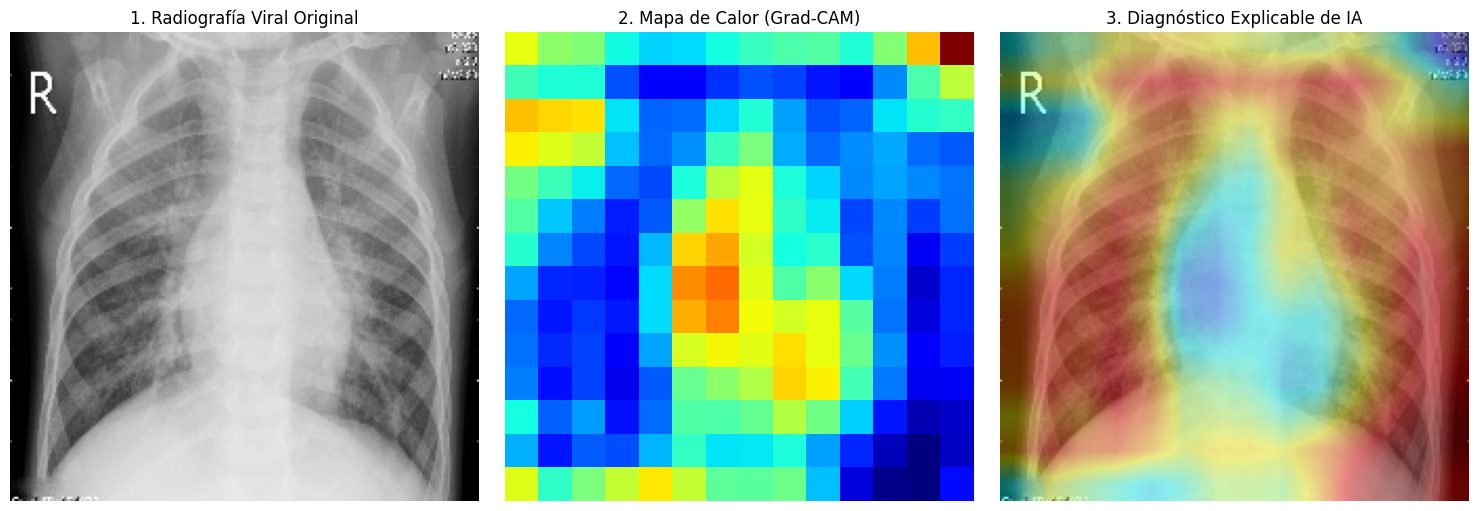


Probabilidad de Neumonía detectada por el modelo: 85.61%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

# 1. Definir la ruta de tu imagen
ruta_imagen_prueba = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/VIRUS-1056329-0001.jpeg'

# 2. Cargar y preprocesar la imagen
img = image.load_img(ruta_imagen_prueba, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normalización
img_array_batch = np.expand_dims(img_array, axis=0)

# 3. SOLUCIÓN AL ERROR: Reconstruir el modelo en formato Funcional
base_model = modelo_optimizado.layers[0]

# Tomamos la entrada original del VGG16
entradas = base_model.input

# Obtenemos la capa convolucional intermedia (la que vigilará el mapa de calor)
conv_output = base_model.get_layer('block5_conv3').output

# Reconstruimos las capas superiores (cabeza) conectándolas a la salida del VGG16
x = base_model.output
for layer in modelo_optimizado.layers[1:]:
    x = layer(x)

# Creamos un nuevo modelo seguro para extraer los gradientes
grad_model = tf.keras.models.Model(
    inputs=entradas,
    outputs=[conv_output, x]
)

# 4. Calcular los gradientes con GradientTape
with tf.GradientTape() as tape:
    # Pasamos la imagen por nuestro nuevo modelo
    conv_outputs, predictions = grad_model(img_array_batch)
    loss = predictions[:, 0]

# 5. Extraer gradientes y procesar el mapa de calor
grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# 6. Superponer el mapa de calor en la imagen original
img_original = cv2.imread(ruta_imagen_prueba)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original = cv2.resize(img_original, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Mezclamos la imagen original con el mapa de calor
imagen_superpuesta = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

# 7. Visualizar los resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_original)
plt.title('1. Radiografía Viral Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title('2. Mapa de Calor (Grad-CAM)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_superpuesta)
plt.title('3. Diagnóstico Explicable de IA')
plt.axis('off')

plt.tight_layout()
plt.show()

# Imprimir la probabilidad
prob = predictions.numpy()[0][0]
print(f"\nProbabilidad de Neumonía detectada por el modelo: {prob*100:.2f}%")

In [ ]:
#Resumen técnico de las arquitecturas

print("=== RESUMEN MODELO CNN DESDE CERO ===")
modelo.summary()

print("\n=== RESUMEN MODELO VGG16 OPTIMIZADO ===")
modelo_optimizado.summary()

=== RESUMEN MODELO CNN DESDE CERO ===


NameError: name 'modelo' is not defined